In [132]:
import pytreenet as ptn
from copy import deepcopy
import numpy as np
import cmath
#np.random.seed(57643)

# Initialize state with product of coherent states |$\alpha$>


In [133]:
from qutip import coherent
def product_state(ttn, bond_dim=2 , physical_dim= 2):
    product_state = deepcopy(ttn)
    #A = np.array([1/np.sqrt(2),1/np.sqrt(2)])
    A = np.array([0,1])
    alpha = 1
    #A = np.array(coherent(physical_dim , alpha).full())
    for node_id in product_state.nodes.keys():
        n = product_state.tensors[node_id].ndim - 1
        tensor = A.reshape((1,) * n + (physical_dim,))
        T = np.pad(tensor, n*((bond_dim, bond_dim),) + ((0, 0),))
        product_state.tensors[node_id] = T
        product_state.nodes[node_id].link_tensor(T)  
    return product_state

# Initialize vectorized_pho

In [134]:
# local physical dimension
d = 2

shapes = {
    (0, 0): (3, 5, 6, d),
    (0, 1): (3, 7, d),
    (0, 2): (7, 8, d),
    (1, 0): (5, 5, d),
    (1, 1): (9, d),
    (1, 2): (8, d),
    (2, 0): (5, 6, d),
    (2, 1): (6, 9, 3, d),
    (2, 2): (3, d)
}


sites = {
    (i, j): ptn.random_tensor_node(shapes[(i, j)], identifier=f"Site({i},{j})") for i in range(3) for j in range(3)
}

vectorized_pho = ptn.TreeTensorNetworkState()

vectorized_pho.add_root(sites[(0, 0)][0], sites[(0, 0)][1])

connections = [
    ((0, 0), (0, 1), 0, 0),
    ((0, 1), (0, 2), 1, 0),
    ((0, 2), (1, 2), 1, 0),
    ((0, 0), (1, 0), 1, 0),
    ((1, 0), (2, 0), 1, 0),
    ((2, 0), (2, 1), 1, 0),
    ((2, 1), (1, 1), 1, 0),
    ((2, 1), (2, 2), 2, 0)]


for (parent, child, parent_leg, child_leg) in connections:
    parent_id = f"Site({parent[0]},{parent[1]})"
    child_id = f"Site({child[0]},{child[1]})"
    vectorized_pho.add_child_to_parent(sites[child][0], sites[child][1], child_leg, parent_id, parent_leg)

# vectorized_pho = product_state(vectorized_pho , bond_dim=4, physical_dim = d)

nodes = {
    (i, j): (ptn.Node(tensor=vectorized_pho.tensors[f"Site({i},{j})"] , identifier=f"Node({i},{j})"), vectorized_pho.tensors[f"Site({i},{j})"]) for i in range(3) for j in range(3)
}

vectorized_pho.add_child_to_parent(nodes[(0,0)][0], nodes[(0,0)][1], 2, "Site(0,0)", 2)

connections = [
    ((0, 0), (0, 1), 1, 0),
    ((0, 1), (0, 2), 1, 0),
    ((0, 2), (1, 2), 1, 0),
    ((0, 0), (1, 0), 2, 0),
    ((1, 0), (2, 0), 1, 0),
    ((2, 0), (2, 1), 1, 0),
    ((2, 1), (1, 1), 1, 0),
    ((2, 1), (2, 2), 2, 0),]

for (parent, child, parent_leg, child_leg) in connections:
    parent_id = f"Node({parent[0]},{parent[1]})"
    vectorized_pho.add_child_to_parent(nodes[child][0], nodes[child][1], child_leg, parent_id, parent_leg)

In [135]:
def get_neighbors_Site(x, y, Lx, Ly):
  neighbors = []
  
  # Right neighbor
  if x < Lx - 1:
      neighbors.append(f"Site({x+1},{y})")
  
  # Up neighbor
  if y < Ly - 1:
      neighbors.append(f"Site({x},{y+1})")
  
  return neighbors

def get_neighbors_Node(x, y, Lx, Ly):
  neighbors = []

  # Right neighbor
  if x < Lx - 1:
      neighbors.append(f"Node({x+1},{y})")
  
  # Up neighbor
  if y < Ly - 1:
      neighbors.append(f"Node({x},{y+1})")
  
  return neighbors

In [136]:
def Liouville(t, U, gamma, m, L, Lx, Ly, d):
    creation_op, annihilation_op, number_op = ptn.bosonic_operators(d)
    
    conversion_dict = {
        "b^dagger": creation_op,
        "b": annihilation_op,
        f"I{d}": np.eye(d)
    }
    
    conversion_dict.update({
        "it * b^dagger": t*1j * creation_op,
        "it * b": t*1j * annihilation_op,
        "-iU * n * (n - 1)": -U*1j * number_op @ (number_op - np.eye(d)),
        "im*n": m*1j*number_op
    })
    
    terms = []
    
    # Hopping terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            neighbors = get_neighbors_Site(x, y, Lx, Ly)            
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "it * b^dagger", neighbor: "b"}))
                terms.append(ptn.TensorProduct({current_site: "it * b", neighbor: "b^dagger"}))
                

    
    # On-site interaction terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "-iU * n * (n - 1)"}))

    # Chemical potential terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "im*n"}))        
    
    H1 = ptn.Hamiltonian(terms, conversion_dict)
    
    conversion_dict = {
        "b^dagger.T": creation_op.T,
        "b.T": annihilation_op.T,
        f"I{d}": np.eye(d)
    }
    
    conversion_dict.update({
        "-it * b^dagger.T": -t*1j * creation_op.T,
        "-it * b.T": -t*1j * annihilation_op.T,
        "iU * n * (n - 1).T": (U*1j * number_op @ (number_op - np.eye(d))).T,
        "-im*n.T": -m*1j* number_op.T
    })
    
    terms = []
    
    # Hopping terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            neighbors = get_neighbors_Node(x, y, Lx, Ly)
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "-it * b^dagger.T", neighbor: "b.T"}))
                terms.append(ptn.TensorProduct({current_site: "-it * b.T", neighbor: "b^dagger.T"}))

    # On-site interaction terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "iU * n * (n - 1).T"}))    

    # Chemical potential terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "-im*n.T"}))
            
    H2 = ptn.Hamiltonian(terms, conversion_dict)
    H1.__add__(H2)

        
    conversion_dict = {    
    "L": np.sqrt(gamma) * L,
    "L^dagger.T": np.sqrt(gamma) * L.conj(),
    "-1/2 (L^dagger @ L) " : -1/2 * gamma * L.conj().T @ L,
    "-1/2 (L^dagger @ L).T": -1/2 * gamma * (L.conj().T @ L).T}
    
    terms = []
    for x in range(Lx):
        for y in range(Ly):
            out_site = f"Node({x},{y})"
            in_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({in_site: "L" , out_site: "L^dagger.T"}))
            terms.append(ptn.TensorProduct({in_site: "-1/2 (L^dagger @ L) "}))
            terms.append(ptn.TensorProduct({out_site: "-1/2 (L^dagger @ L).T"}))

    H3 = ptn.Hamiltonian(terms, conversion_dict)
    H1.__add__(H3)
    return H1

In [137]:
def Number_op_total(Lx, Ly, dim=2):
    creation_op, annihilation_op, number_op = ptn.bosonic_operators(dim)
    conversion_dict = {"n": number_op , f"I{dim}": np.eye(dim)}
    for dim in range(2, 200):
        conversion_dict[f"I{dim}"] = np.eye(dim)

    terms = []
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Vertex({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "n"}))

    return ptn.Hamiltonian(terms, conversion_dict) 

def BoseHubbard_ham(t, U, m, Lx, Ly, d):
    creation_op, annihilation_op, number_op = ptn.bosonic_operators(d)

    conversion_dict = {
        "b^dagger": creation_op,
        "b": annihilation_op,
        f"I{d}": np.eye(d)}
    
    conversion_dict.update({
        "-t * b^dagger": -t * creation_op,
        "-t * b": -t * annihilation_op,
        "U * n * (n - 1)": U * number_op @ (number_op - np.eye(d)),
        "-m*n": -m * number_op
    })

    for dim in range(2, 200):
        conversion_dict[f"I{dim}"] = np.eye(dim)    
    terms = []
    
    # Hopping terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            neighbors = get_neighbors_Site(x, y, Lx, Ly)
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "-t * b^dagger", neighbor: "b"}))
                terms.append(ptn.TensorProduct({current_site: "-t * b", neighbor: "b^dagger"}))


    # On-site interaction terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "U * n * (n - 1)"}))
    
    # Chemical potential terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "-m*n"}))

    return ptn.Hamiltonian(terms, conversion_dict)



# Define SecondOrderOneSiteTDVP
gamma = 0

In [138]:
t = 0.4
U = 0.8
m = 0.4
creation_op, annihilation_op, number_op = ptn.bosonic_operators(d)
L = annihilation_op 
gamma = 10

ket , bra = ptn.devectorize_pho(vectorized_pho , connections)

# TTNO : Number operator
N = Number_op_total(3, 3, d)
N = N.pad_with_identities(ket, symbolic= True)
N = ptn.TTNO.from_hamiltonian(N, ket)

# TTNO : Bose-Hubbard Hamiltonian
H = BoseHubbard_ham(t, U, m, 3, 3, d)
H = H.pad_with_identities(vectorized_pho, symbolic= True)
H = ptn.TTNO.from_hamiltonian(H, vectorized_pho)

# TTNO : Identity operator
I_pho = ptn.TTNO.Identity(vectorized_pho)
I_ket = ptn.TTNO.Identity(ket)
# TTNO : Liouville operator 
H1 = Liouville(t, U, gamma, m ,L, 3, 3, d)
H1 = H1.pad_with_identities(vectorized_pho , symbolic= True)
L_fancy = ptn.TTNO.from_hamiltonian(H1, vectorized_pho)

connections = [ ((0, 0), (0, 1), 1, 0),
                ((0, 1), (0, 2), 1, 0),
                ((0, 2), (1, 2), 1, 0),
                ((0, 0), (1, 0), 2, 0),
                ((1, 0), (2, 0), 1, 0),
                ((2, 0), (2, 1), 1, 0),
                ((2, 1), (1, 1), 1, 0),
                ((2, 1), (2, 2), 2, 0)]

# vectorized_pho = ptn.normalize_ttn_Lindblad_X(vectorized_pho, "Site(0,0)")
tdvp_Lindblad = ptn.SecondOrderOneSiteTDVP(initial_state = vectorized_pho,
                                            hamiltonian = L_fancy,
                                            time_step_size = 0.1,
                                            final_time = 1,
                                            operators = N,
                                            connections = connections)

In [139]:
b

NameError: name 'b' is not defined

In [142]:
vectorized_pho.orthogonality_center_id

'Node(1,1)'

In [141]:
tdvp_Lindblad.run_one_time_step_copy()
tdvp_Lindblad.run_one_time_step_copy()
tdvp_Lindblad.run_one_time_step_copy()
tdvp_Lindblad.run_one_time_step_copy()
vectorized_pho = tdvp_Lindblad.state

In [143]:
vectorized_pho = deepcopy(tdvp_Lindblad.state)
vectorized_pho_str = deepcopy(tdvp_Lindblad.state)

In [144]:
ket , bra = ptn.devectorize_pho(vectorized_pho , connections)
# compute <bra|ket>
bra_ket = ptn.bra_ket(vectorized_pho, connections)
bra_ket , cmath.phase(bra_ket) , np.abs(bra_ket)

((0.9780865647040965-0.20819863579124503j),
 -0.20973287488502282,
 0.999999999999998)

In [145]:
vectorized_pho.canonical_form("Node(1,1)")
ket , bra = ptn.devectorize_pho(vectorized_pho , connections)
bra_ket = ptn.bra_ket(vectorized_pho, connections)
bra_ket , cmath.phase(bra_ket) , np.abs(bra_ket)

((0.9780865647040974-0.20819863579124487j),
 -0.20973287488502246,
 0.9999999999999989)

In [121]:
vectorized_pho.canonical_form("Node(1,1)")
vectorized_pho = ptn.adjust_ttn1_structure_to_ttn2(vectorized_pho, vectorized_pho_str)
ket , bra = ptn.devectorize_pho(vectorized_pho , connections)
bra_ket = ptn.bra_ket(vectorized_pho, connections)
bra_ket , cmath.phase(bra_ket) , np.abs(bra_ket)

((0.8262878460273482+0.2841391793049318j),
 0.33120726350443674,
 0.8737772471909503)

In [116]:
ket , bra = ptn.devectorize_pho(vectorized_pho , connections)
bra_ket = ptn.bra_ket(vectorized_pho, connections)
n = len(ket.nodes)
norm_factor = 1 / np.sqrt(bra_ket ** (1/n))
norm_factor , cmath.phase(norm_factor)

((1.0030855033134116-0.01675636959923521j), -0.01670327322669692)

In [117]:
for ket_id in [node.identifier for node in ket.nodes.values()]:
    T = ket.tensors[ket_id].astype(complex)
    T *= norm_factor
    ket.tensors[ket_id] = T
    ket.nodes[ket_id].link_tensor(T)

    T = bra.tensors[ket_id].astype(complex)
    T *= norm_factor.con()
    bra.tensors[ket_id] = T
    bra.nodes[ket_id].link_tensor(T)

AttributeError: 'numpy.complex128' object has no attribute 'con'

In [133]:
bra = bra.conjugate()
bra_ket = ptn.contract_two_ttns(bra , ket)
bra_ket , cmath.phase(bra_ket)

((0.9676216256056456-0.252405209257431j), -0.25516514428540366)

In [134]:
operator = N
new_dim = ket.tensors[ket.root_id + "_R"].shape[-1]
op_tensor = np.eye(new_dim).reshape((1, new_dim, new_dim))
operator.tensors[operator.root_id + "_R"] = op_tensor
operator.nodes[operator.root_id + "_R"].link_tensor(op_tensor)

operator = ptn.adjust_ttno_structure_to_ttn(operator, ket)
op_ket = ptn.contract_ttno_with_ttn(operator, ket)
exp_val = ptn.contract_two_ttns(op_ket , bra)
exp_val , cmath.phase(exp_val)

((4.05601619272834-0.6700769434979235j), -0.1637268482439665)

In [19]:
tdvp_Lindblad.run_Lindblad(evaluation_time=1)
times = tdvp_Lindblad.times

  0%|          | 0/101 [00:00<?, ?it/s]

(9+0j)


  2%|▏         | 2/101 [00:01<01:12,  1.37it/s]

(9.00000000000001-6.2585848656793136e-18j)


  3%|▎         | 3/101 [00:02<01:39,  1.02s/it]

(8.999999999999996-6.289642602017363e-18j)


  3%|▎         | 3/101 [00:03<02:09,  1.32s/it]


KeyboardInterrupt: 

AssertionError: Currently there are no results!

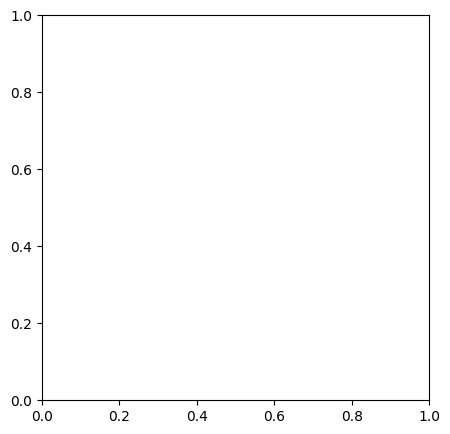

In [9]:
import matplotlib.pyplot as plt

fig1, axs1 = plt.subplots(1, 1, sharex=True, figsize=(5, 5))

axs1.plot( tdvp_Lindblad.operator_results()[0] , label="gamma = 0")
axs1.plot( tdvp_Lindblad.operator_results()[0] , label="gamma = 0")

#axs1.plot( np.imag(norm_2) , label="gamma = 0")

axs1.set_xlabel("Time $t$")
axs1.set_ylabel("Total Occupation ")
axs1.grid(True)
axs1.legend()

In [114]:
from qutip import *
import numpy as np

# Define parameters
t = 0.4  # Hopping strength
U = 0.8  # On-site interaction strength
m = 0.4  # Chemical potential
gamma_relax = 1  # Relaxation rate

# Reduced lattice dimensions
Nx = 3  # Number of sites along x-direction
Ny = 3  # Number of sites along y-direction
N = Nx * Ny  # Total number of sites

# Reduced maximum number of bosons per site
nmax = 1

# Precompute the operators for each site
a_list = []
adag_list = []
n_list = []
si = qeye(nmax + 1)  # Identity operator for a single site
for n in range(N):
    op_list = [si] * N
    op_list[n] = destroy(nmax + 1)
    a_op = tensor(op_list)
    a_list.append(a_op)
    adag_list.append(a_op.dag())
    n_list.append(a_op.dag() * a_op)


# Function to map 2D lattice coordinates (i, j) to a site index
def site(i, j):
    return i + j * Nx

# Initialize the Hamiltonian
H = 0

# Build the Hamiltonian by summing over sites
for i in range(Nx):
    for j in range(Ny):
        n = site(i, j)
        H += 0.5 * U * n_list[n] * (n_list[n] - 1) - m * n_list[n]
        if i < Nx - 1:
            n_right = site(i + 1, j)
            H += -t * (adag_list[n] * a_list[n_right] + adag_list[n_right] * a_list[n])
        if j < Ny - 1:
            n_up = site(i, j + 1)
            H += -t * (adag_list[n] * a_list[n_up] + adag_list[n_up] * a_list[n])

# Initial state: product state of maximum occupation

#psi0 = tensor([basis(nmax + 1, nmax) for _ in range(N)]).unit()
#psi0 = tensor([(basis(nmax + 1, 0) + 1j * basis(nmax + 1, 1)).unit() for _ in range(N)])
alpha = 1
psi0 = 1j *tensor([coherent(nmax + 1, alpha) for _ in range(N)])
# Reduced simulation time and increased time step
total_time = 0.1  # Total time in seconds
time_step = 0.001  # Time step in seconds
tlist = np.arange(0, total_time + time_step, time_step)

# Define collapse operators (for the Lindblad equation)
custom_matrix = Qobj([[0, 1], [0, 0]])
jump_operator = []
si = qeye(nmax + 1) 
for n in range(N):
  op_list = [si] * N  # Create a list of identity operators
  op_list[n] = custom_matrix  # Replace the n-th site with the custom matrix
  custom_op = tensor(op_list)  # Create the tensor product
  jump_operator.append(custom_op)

c_ops = [np.sqrt(gamma_relax) * a for a in a_list]


# Observables to calculate - total particle number
N_total = sum(n_list)

# Solve the Schrödinger equation (more efficient for this case)
result = mesolve(H, psi0, tlist, c_ops, [N_total])

# Extract expectation values
total_number = result.expect[0]

# Print results
print("Time evolution of total particle number:")
for t, n in zip(tlist, total_number):
    print(f"Time: {t:.2f}, Total number: {n:.4f}")

Time evolution of total particle number:
Time: 0.00, Total number: 6.3727
Time: 0.00, Total number: 6.3663
Time: 0.00, Total number: 6.3599
Time: 0.00, Total number: 6.3536
Time: 0.00, Total number: 6.3472
Time: 0.01, Total number: 6.3409
Time: 0.01, Total number: 6.3345
Time: 0.01, Total number: 6.3282
Time: 0.01, Total number: 6.3219
Time: 0.01, Total number: 6.3156
Time: 0.01, Total number: 6.3093
Time: 0.01, Total number: 6.3029
Time: 0.01, Total number: 6.2966
Time: 0.01, Total number: 6.2904
Time: 0.01, Total number: 6.2841
Time: 0.01, Total number: 6.2778
Time: 0.02, Total number: 6.2715
Time: 0.02, Total number: 6.2652
Time: 0.02, Total number: 6.2590
Time: 0.02, Total number: 6.2527
Time: 0.02, Total number: 6.2465
Time: 0.02, Total number: 6.2402
Time: 0.02, Total number: 6.2340
Time: 0.02, Total number: 6.2278
Time: 0.02, Total number: 6.2215
Time: 0.03, Total number: 6.2153
Time: 0.03, Total number: 6.2091
Time: 0.03, Total number: 6.2029
Time: 0.03, Total number: 6.1967
Ti

c:\Users\edpou\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\edpou\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


NameError: name 'total_number' is not defined

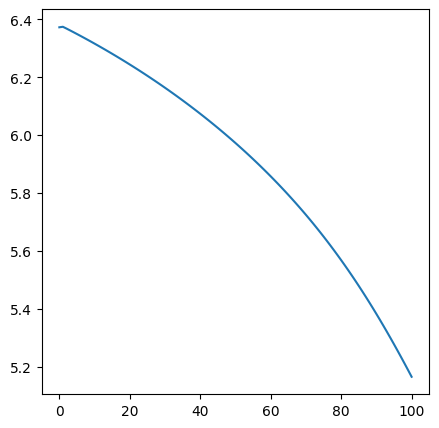

In [19]:
import matplotlib.pyplot as plt

fig1, axs1 = plt.subplots(1, 1, sharex=True, figsize=(5, 5))

axs1.plot( tdvp_Lindblad.operator_results()[0] , label="Lindblad")
#axs1.plot( np.imag(tdvp_Lindblad.operator_results()[0]) , label="Lindblad")

axs1.plot( total_number , label="Exact")

axs1.set_xlabel("Time $t$")
axs1.set_ylabel("Total Occupation ")
axs1.grid(True)
axs1.legend()